# Ecriture de chiffres

## Code présent dans le sujet

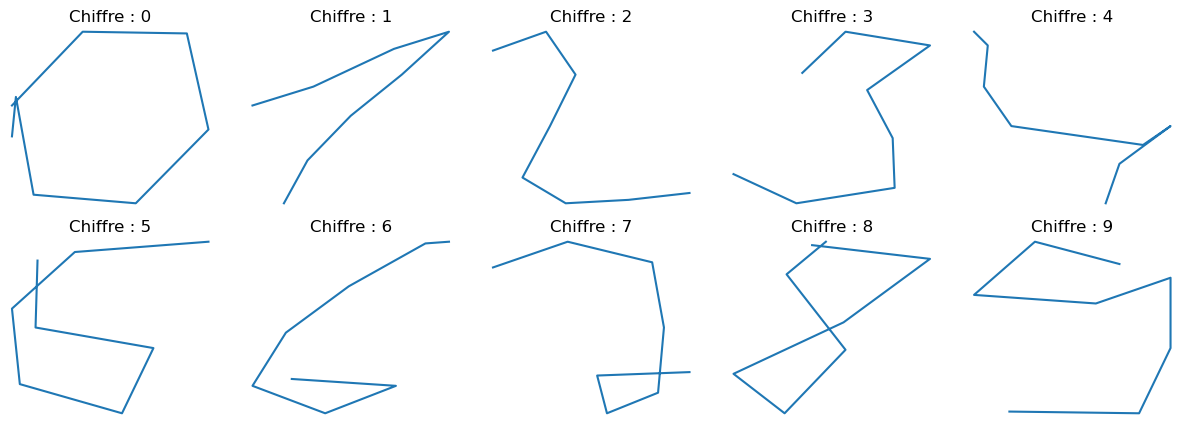

In [1]:
import numpy
import pandas
import matplotlib.pyplot as plt

pen_tes = pandas.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/pendigits/pendigits.tes", 
                          header=None)
pen_tra = pandas.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/pendigits/pendigits.tra", 
                          header=None)
pen = pandas.concat([pen_tra, pen_tes], ignore_index = True)

a = [c + n for c, n in zip(["x", "y"] * 8, [str(x) for x in range(1, 9) for i in range(2)])]
a.append("chiffre")
pen.columns = a

xN = ["x" + str(i + 1) for i in range(8)]
yN = ["y" + str(i + 1) for i in range(8)]
xyN = [a + b for a,b in zip(["x", "y"] * 8, [str(i + 1) for i in range(8) for j in range(2)])]

def dessin(p, x, y, chiffre):
    p.plot(x, y)
    p.set_title("Chiffre : " + str(chiffre))
    p.axis("off")
    p.set_xlim([-1, 101])
    p.set_ylim([-1, 101])
    
sub = [pen.query("chiffre == " + str(i)).reset_index(drop = True) for i in range(10)]
sub_first_xyc = [[s.loc[0, xN], s.loc[0, yN], s.loc[0, "chiffre"]] for s in sub]

fig = plt.figure(figsize = (15, 5))
for i in range(10):
    ax = fig.add_subplot(2, 5, i + 1) # on ajoute un sous-graphique à la position i+1
    dessin(ax, sub_first_xyc[i][0], sub_first_xyc[i][1], sub_first_xyc[i][2])

## Calcul des coordonnées moyennes

- Calcul des coordonnées moyennes pour représenter le *tracé moyen* de chaque chiffre

In [2]:
cmoy = pen.groupby("chiffre").mean().round(2)
cmoy

,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,x6,y6,x7,y7,x8,y8
chiffre,,,,,,,,,,,,,,,,
0,35.37,86.06,11.58,58.31,14.94,19.60,51.17,7.29,85.94,31.30,89.29,68.49,59.01,89.31,22.10,75.24
1,14.70,61.39,44.35,77.94,69.86,89.51,77.50,79.80,67.64,54.06,47.80,32.66,44.60,16.16,59.91,1.38
2,18.39,76.95,42.13,99.39,67.46,79.76,51.28,46.05,19.83,19.38,11.64,9.09,53.06,5.25,98.71,4.17
3,24.78,84.06,56.66,99.52,86.64,84.69,64.53,60.59,82.13,43.22,90.88,17.26,50.01,2.28,3.47,6.24
4,42.96,99.54,22.13,79.38,5.75,51.16,42.83,40.47,85.10,49.56,86.30,59.72,70.99,31.45,62.60,0.00
5,41.24,90.94,42.60,75.83,57.31,59.18,36.46,29.36,26.18,33.15,37.64,50.24,42.83,57.69,59.46,60.31
6,87.52,98.72,51.75,86.72,20.71,58.48,6.94,26.93,32.61,3.14,81.11,11.02,61.57,30.54,11.00,23.35
7,3.50,91.01,45.37,98.25,78.85,80.76,71.27,47.47,52.73,14.93,33.60,18.47,39.51,33.80,81.14,34.31
8,56.95,82.08,39.83,79.62,51.81,51.93,50.56,24.22,35.25,17.07,39.93,36.90,67.78,68.49,49.00,81.40


## Récriture de la fonction `dessin()`

- Amélioration ici de la fonction pour ajouter la possibilité de mettre les points (de 1 à 8)

In [3]:
def dessin(p, x, y, chiffre = None, pos = False, titre = "Chiffre", couleur = "steelblue"):
    p.plot(x, y, color = couleur)
    if (pos):
        for i in range(8):
            p.text(x.iloc[i], y.iloc[i], str(i+1), 
                   va = "center", ha = "center", weight = "bold", size = "x-large")
    if (chiffre):
        p.set_title(titre + " : " + str(chiffre))
    p.axis("off")
    p.set_xlim([-1, 101])
    p.set_ylim([-1, 101])

## Représentation des *chiffres moyens*

- Les chiffres 0, 1, 2, 3, 4, 6 semblent cohérents ;
- Le chiffre 8 paraît concentré sur la zone centrale ;
- Le chiffre 7, bien que presque reconnaissable, semble étonnant ;
- Les chiffres 5 et 9 sont difficilement reconnaissables.

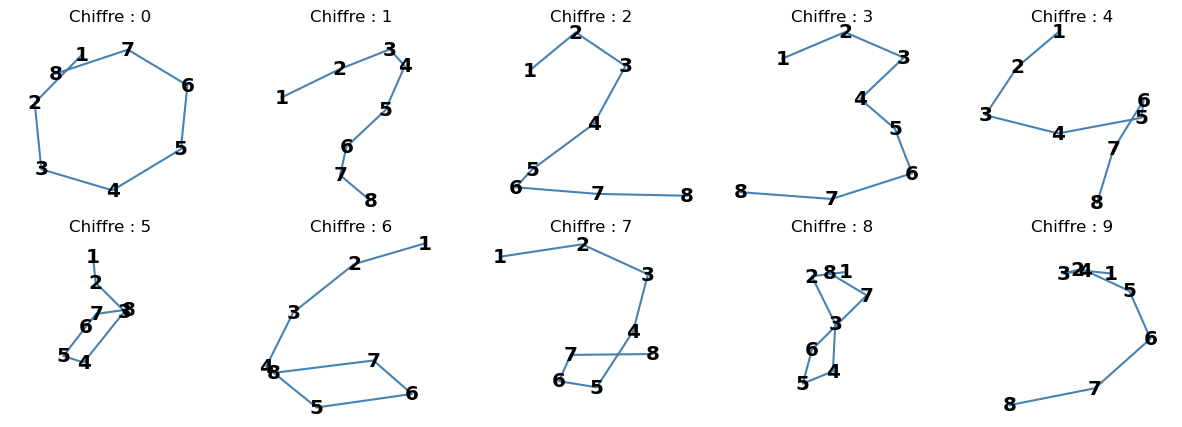

In [4]:
fig = plt.figure(figsize = (15, 5))
for i in range(10):
    ax = fig.add_subplot(2, 5, i + 1)
    dessin(ax, cmoy.loc[i,xN], cmoy.loc[i,yN], str(i), pos = True)

## Et avec l'ensemble des tracés ?

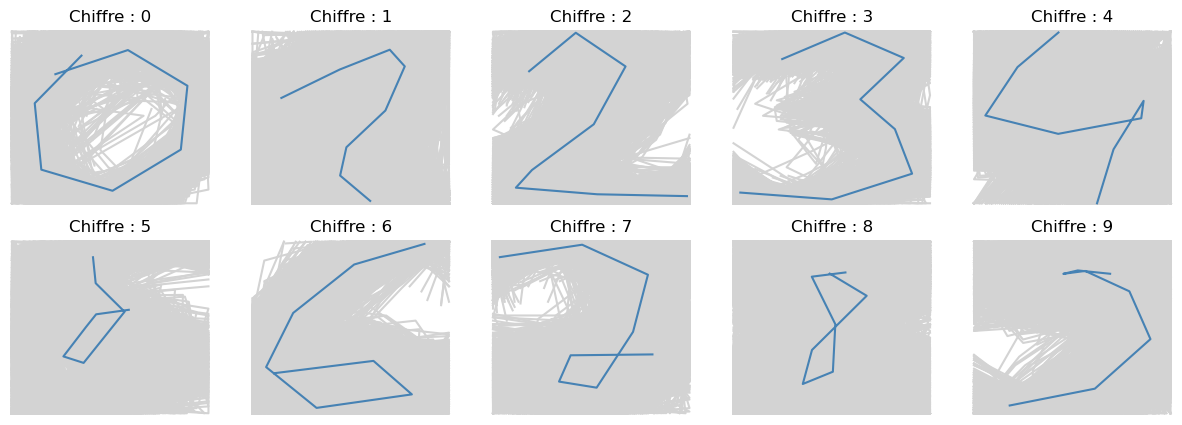

In [5]:
fig = plt.figure(figsize = (15, 5))
for i in range(10):
    ax = fig.add_subplot(2, 5, i + 1)
    t = 1
    for t in range(sub[i].shape[0]):
        dessin(ax, sub[i].loc[t, xN], sub[i].loc[t, yN], couleur = "lightgray")
    dessin(ax, cmoy.loc[i,xN], cmoy.loc[i,yN], str(i), pos = False)

## Représentation des tracés sur un plan en 2D

### sur données originales

- Ensemble de variables avec la même étendue
- Logique de faire sur les données originales

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

pca_original = PCA()
pca_original.fit(pen.loc[:,xyN])
pen_original_pca = pca_original.transform(pen.loc[:,xyN])
pen_original_df = pandas.DataFrame({
    "Dim1" : pen_original_pca[:,0], 
    "Dim2" : pen_original_pca[:,1],
    "Chiffre" : pen["chiffre"]
})

On remarque que le nuage a la forme d'un rectangle avec une légère rotation. Il est par contre difficile de faire une analyse correcte sur chaque chiffre, à cause du chevauchement des sous-nuages.

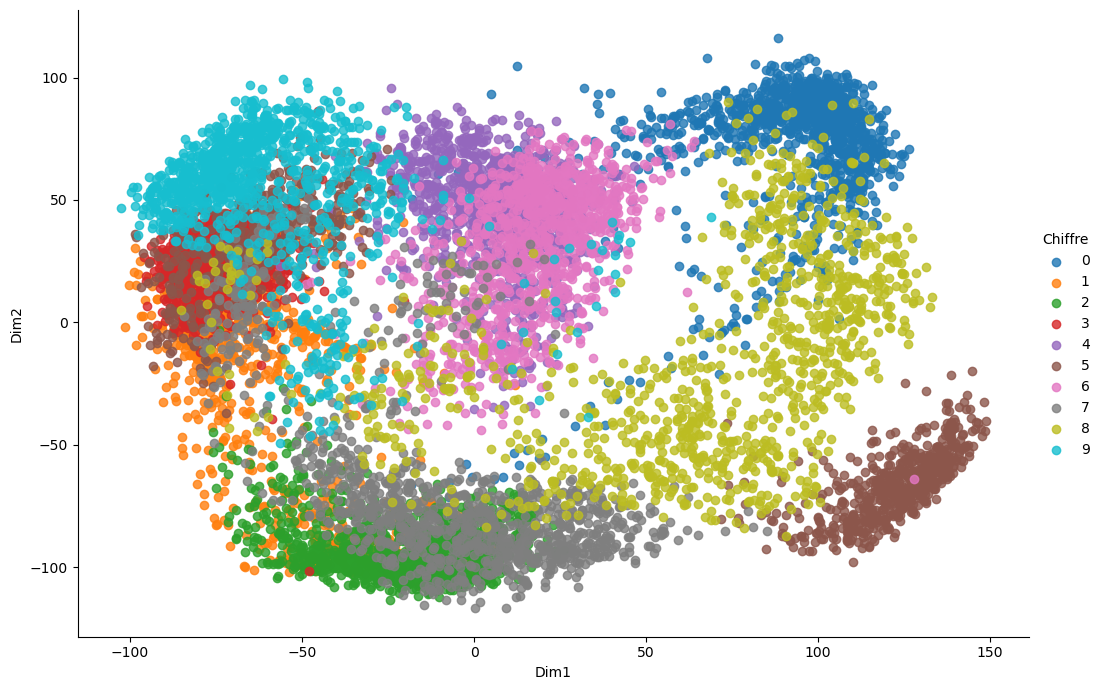

In [7]:
import seaborn
seaborn.lmplot(data = pen_original_df, x = "Dim1", y = "Dim2", hue = "Chiffre",
              fit_reg = False, height = 7, aspect = 1.5)
plt.show()

### Représentation séparée

Il est plus simple d'analyser les chiffres un par un. Pour cela, on représente chaque sous-nuage créé par chaque chiffre séparément. Et on remarque les éléments suivants :

- 2, 3, 4 et 6 : regroupés sur une zone restreinte ;
- 1, 5 (particulièrement), 7, 8 et 9 : avec groupes séparés ;
- 0 : forme allongée courbe.

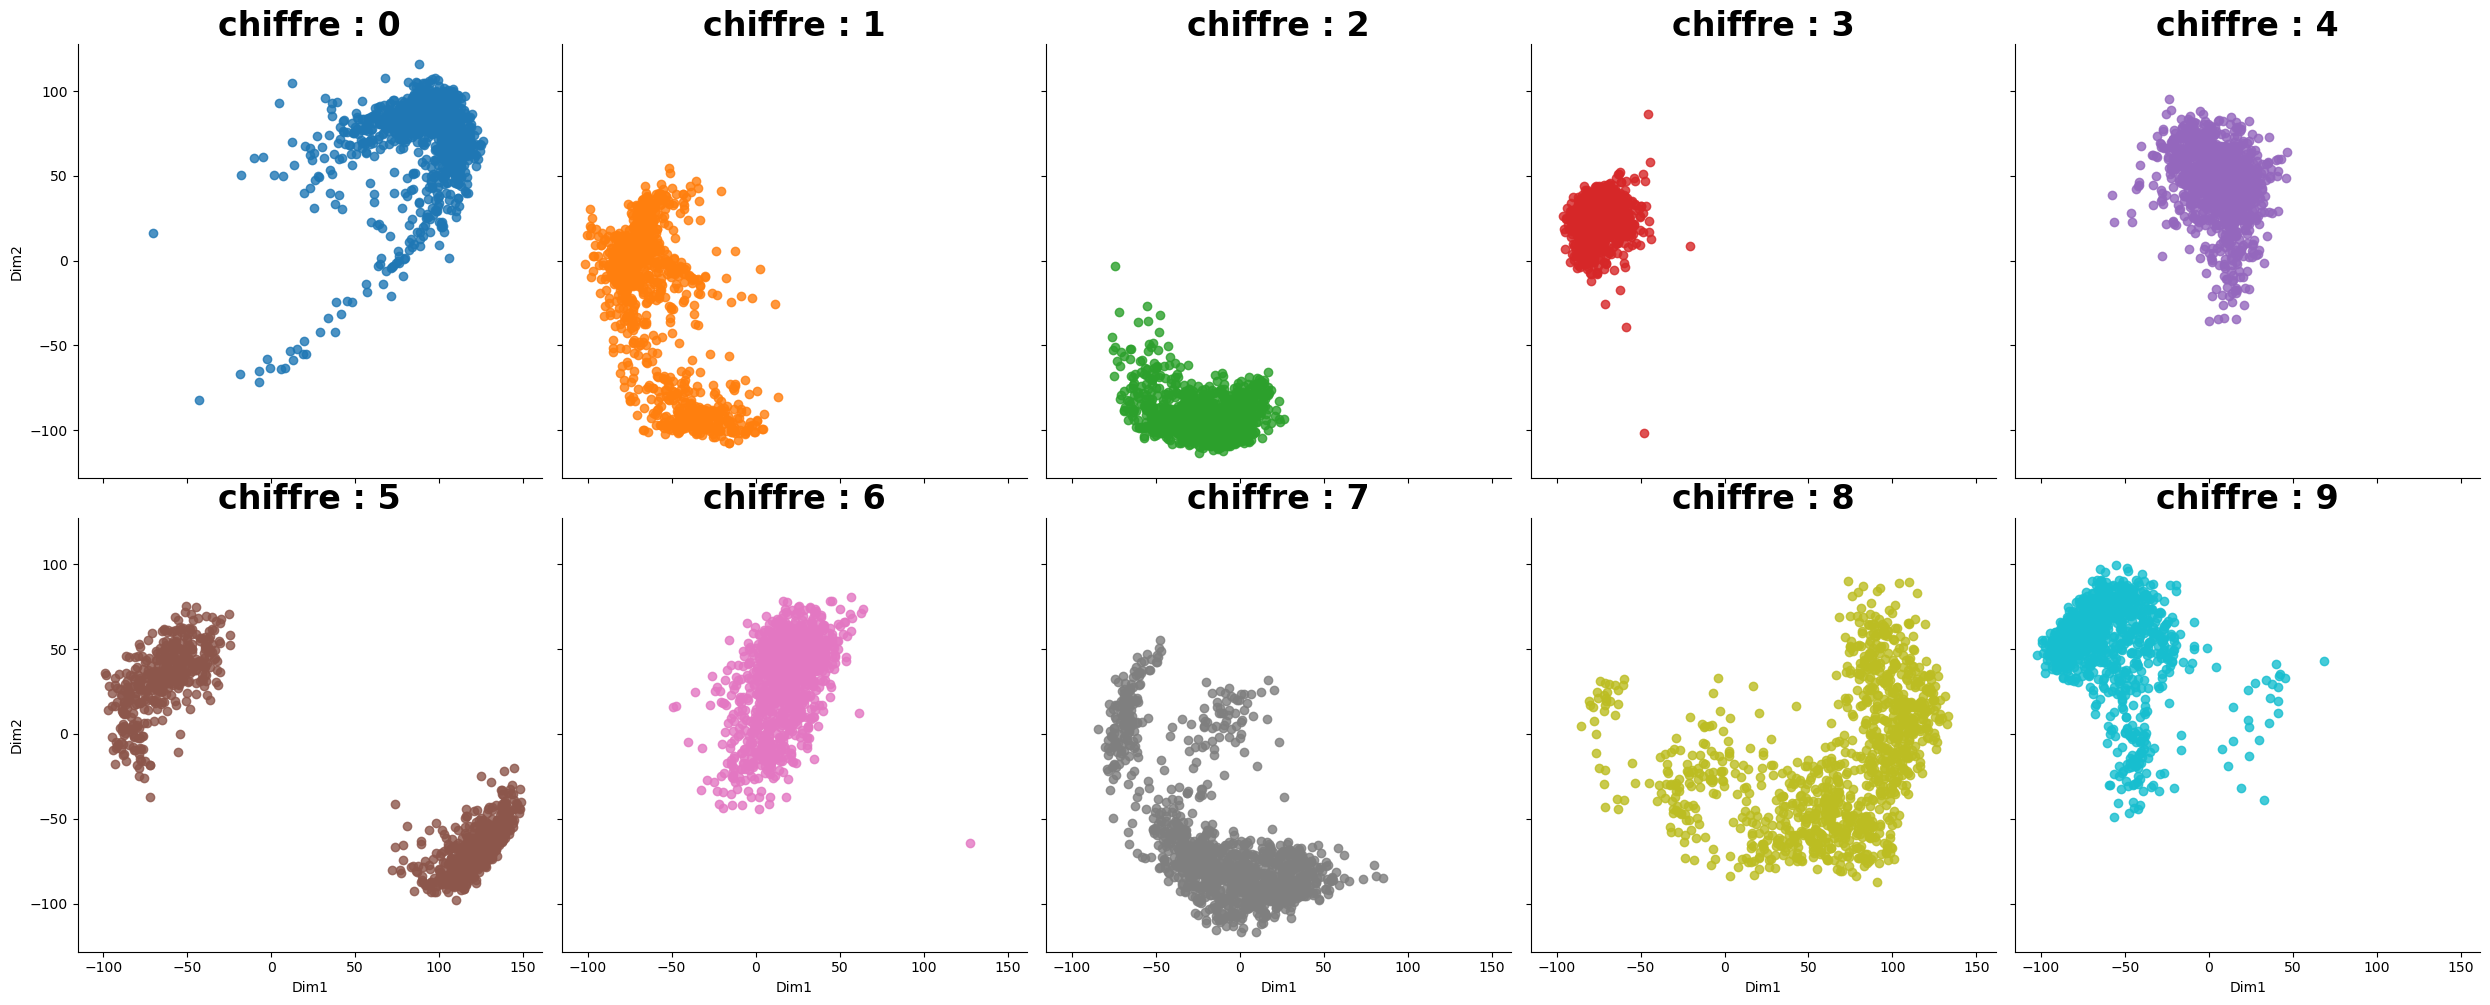

In [8]:
g = seaborn.lmplot(data = pen_original_df, x = "Dim1", y = "Dim2", hue = "Chiffre", 
               col = "Chiffre", col_wrap = 5, fit_reg = False)
g.set_titles(col_template = "chiffre : {col_name}", fontweight = "bold", size = 24)
plt.show()

## Représentation des tracés sur un plan en 2D

### sur données standardisées

- Bien évidemment possible d'appliquer l'ACP sur les données standardisées

In [9]:
pca_scale = PCA()
pca_scale.fit(scale(pen.loc[:,xyN]))
pen_scale_pca = pca_scale.transform(scale(pen.loc[:,xyN]))
pen_scale_df = pandas.DataFrame({
    "Dim1" : pen_scale_pca[:,0], 
    "Dim2" : pen_scale_pca[:,1],
    "Chiffre" : pen["chiffre"]
})

- Forme sphérique due aux valeurs entre 0 et 100 d'une part, et à la standardisation d'autre part

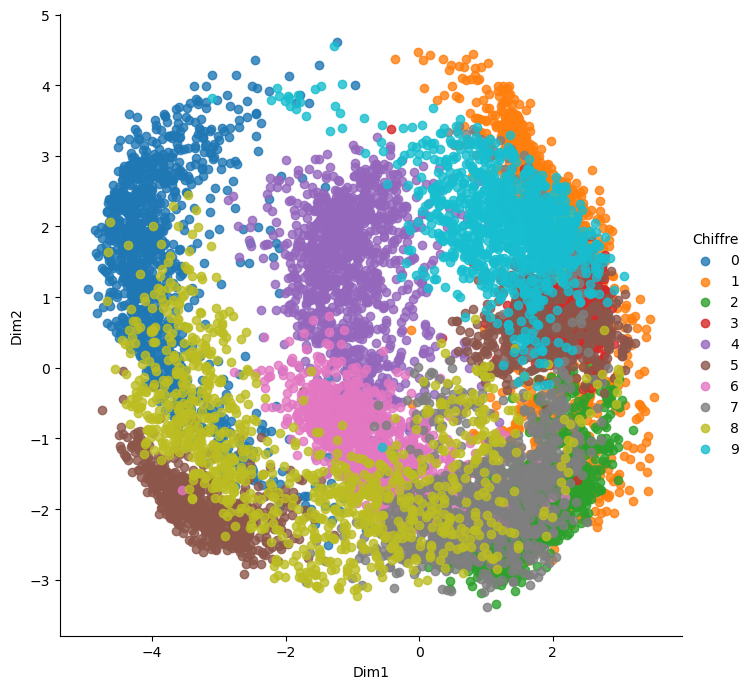

In [10]:
seaborn.lmplot(data = pen_scale_df, x = "Dim1", y = "Dim2", hue = "Chiffre",
              fit_reg = False, height = 7, aspect = 1)
plt.show()

### Représentation séparée

- 2, 3, 4 et 6 : aussi regroupés sur une zone restreinte ;
- 1, 5 (particulièrement), 7, 8 et 9 : encore des groupes séparés ;
- 0 : toujours une forme allongée courbe.

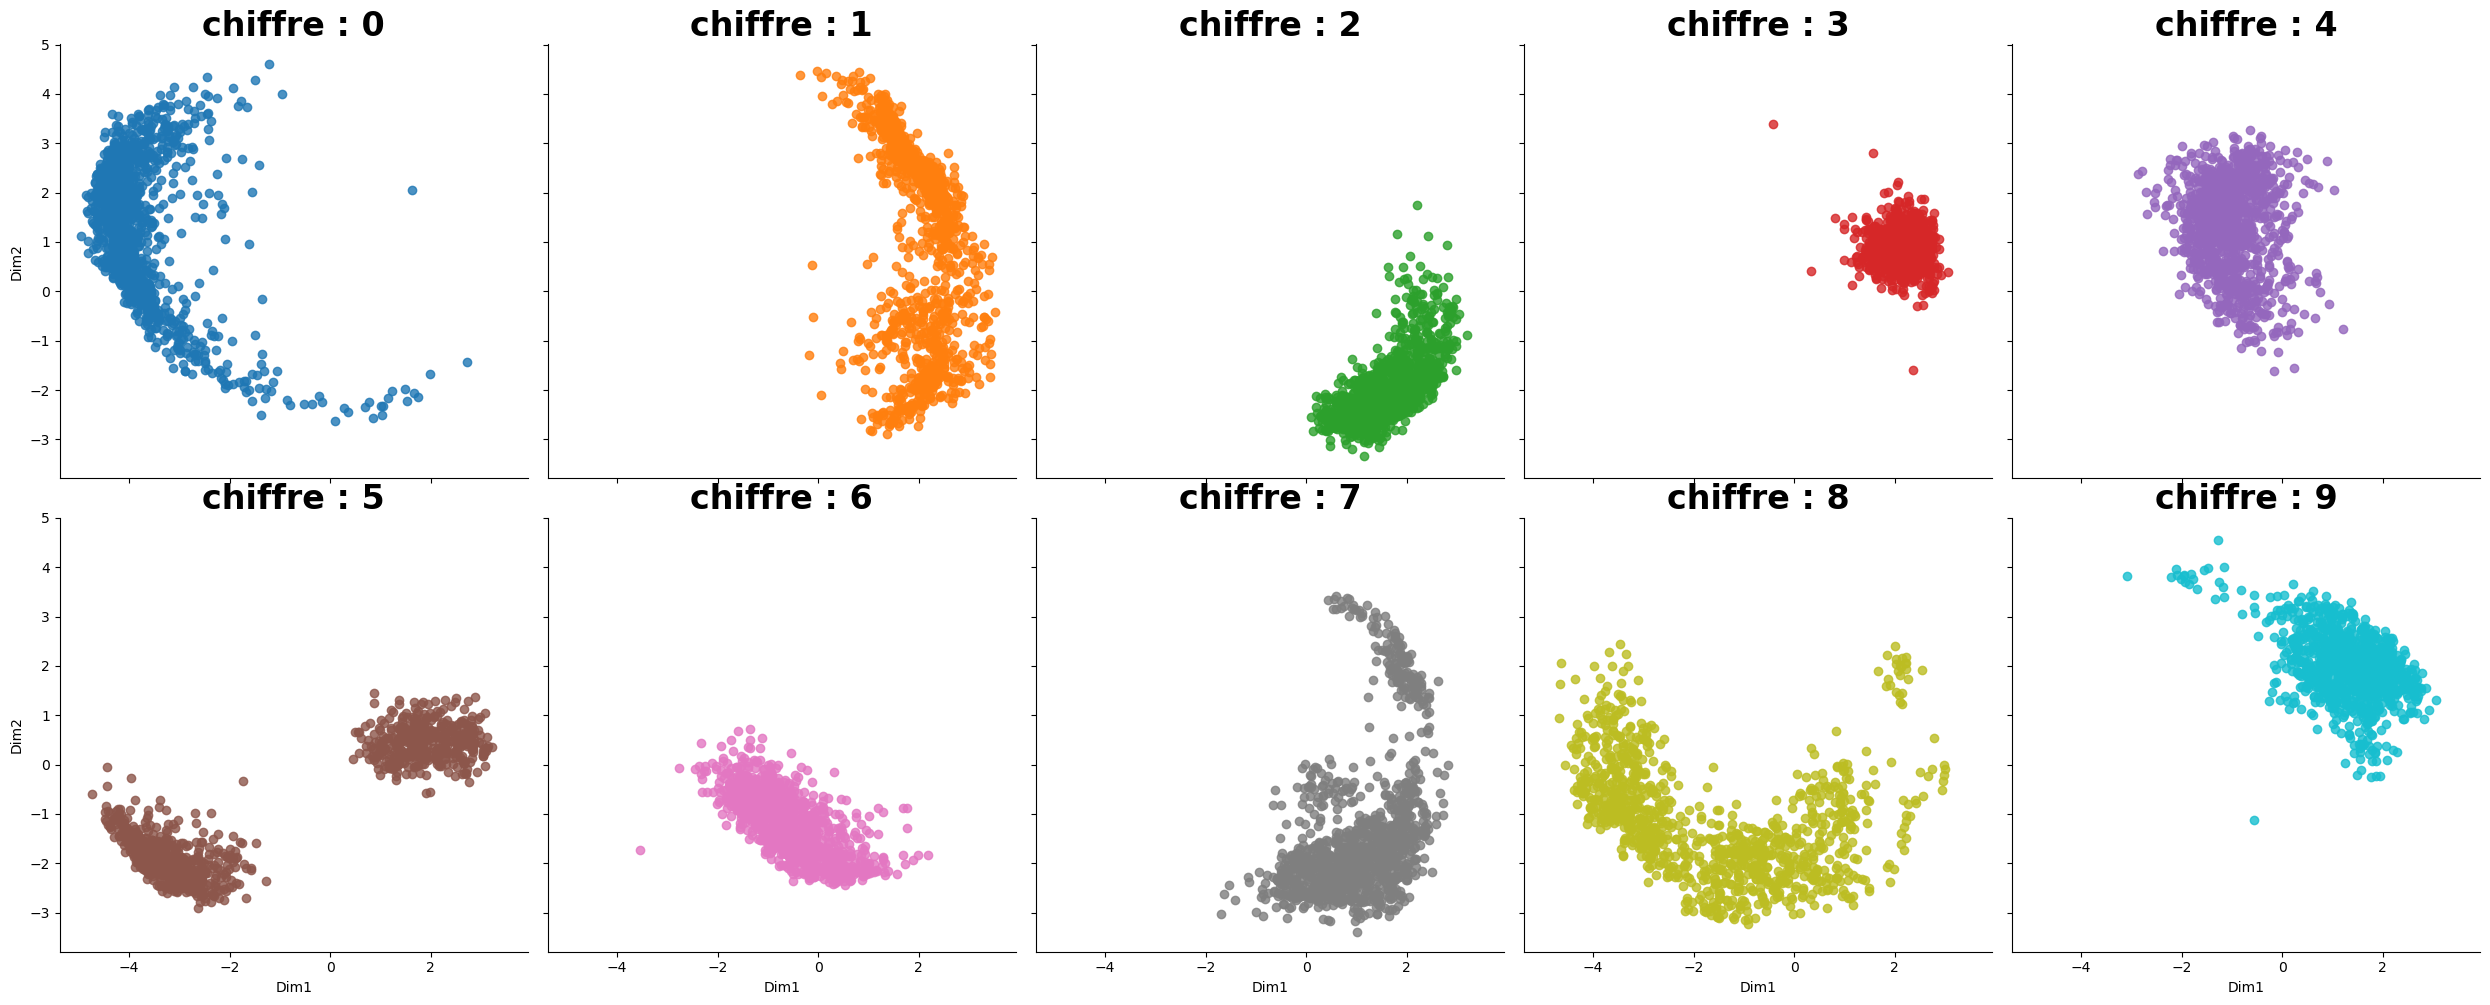

In [11]:
g = seaborn.lmplot(data = pen_scale_df, x = "Dim1", y = "Dim2", hue = "Chiffre", 
               col = "Chiffre", col_wrap = 5, fit_reg = False)
g.set_titles(col_template = "chiffre : {col_name}", fontweight = "bold", size = 24)
plt.show()

## Une autre possibilité : une ACP par chiffre

- Les chiffres 1, 2, 3, 4, 6 et 9 ont un nuage de points très concentré ;
- Le chiffre 5 présente très nettement deux groupes ;
- Les chiffres 7 et 8 semblent avoir des sous-groupes ;
- Le chiffre 0 a toujours un comportement en arc de cercle.

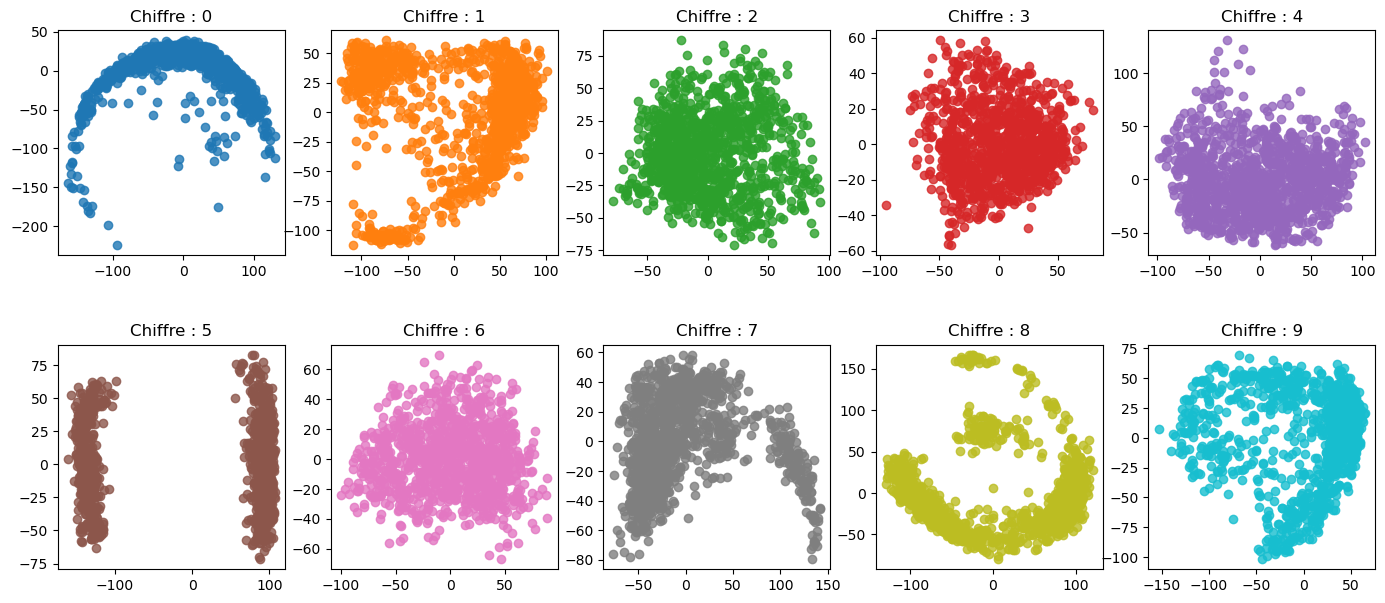

In [12]:
fig = plt.figure(figsize = (17, 7))
for c in range(10):
    pen_chiffre = pen.query("chiffre == @c").loc[:,xyN]
    pca_chiffre = PCA()
    pca_chiffre.fit(pen_chiffre)
    pca_chiffre_pca = pca_chiffre.transform(pen_chiffre)
    ax = fig.add_subplot(2, 5, c + 1)
    ax.title.set_text("Chiffre : " + str(c))
    seaborn.regplot(x = pca_chiffre_pca[:,0], y = pca_chiffre_pca[:,1], 
                    ax = ax, fit_reg = False,
                       color = seaborn.color_palette()[c])

plt.subplots_adjust(hspace = .4)